# 🍜 Ramen Ratings: Data Visualization Lab
**Exploring Global Ramen Preferences with Matplotlib & Seaborn**

---
This notebook explores the Ramen Ratings dataset to uncover patterns in packaging styles, country-level quality, brand performance, and rating distributions. We'll produce 11 visualizations organized into three analytical categories.

## 1. Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_csv('ramen-ratings.csv')

# Clean Stars column — coerce non-numeric to NaN
df['Stars'] = pd.to_numeric(df['Stars'], errors='coerce')
df.dropna(subset=['Stars'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape: {df.shape}')
df.head(10)

Shape: (2577, 5)


,Brand,Variety,Style,Country,Stars
0,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75
1,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00
2,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25
3,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75
4,Ching's Secret,Singapore Curry,Pack,India,3.75
5,Samyang Foods,Kimchi song Song Ramen,Pack,South Korea,4.75
6,Acecook,Spice Deli Tantan Men With Cilantro,Cup,Japan,4.00
7,Ikeda Shoku,Nabeyaki Kitsune Udon,Tray,Japan,3.75
8,Ripe'n'Dry,Hokkaido Soy Sauce Ramen,Pack,Japan,0.25
9,KOKA,The Original Spicy Stir-Fried Noodles,Pack,Singapore,2.50


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2577 entries, 0 to 2576
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    2577 non-null   object 
 1   Variety  2577 non-null   object 
 2   Style    2575 non-null   object 
 3   Country  2577 non-null   object 
 4   Stars    2577 non-null   float64
dtypes: float64(1), object(4)
memory usage: 100.8+ KB


In [4]:
df['Stars'].describe()

,Stars
count,2577.000000
mean,3.654676
std,1.015331
min,0.000000
25%,3.250000
50%,3.750000
75%,4.250000
max,5.000000


### Dataset Overview

The Ramen Ratings dataset contains **~2,500 individual ramen product reviews** across five columns: Brand, Variety, Style (packaging type), Country of origin, and Star rating (0–5 scale). The data spans dozens of countries and hundreds of brands, with Japan, South Korea, and the USA being the most represented. Most ratings cluster in the 3–4 star range, suggesting generally positive but not exceptional global quality perception.

In [5]:
# Generate synthetic Year variable for time-based analysis
np.random.seed(42)
df['Year'] = np.random.randint(2002, 2018, size=len(df))
print('Synthetic Year column added (2002–2017).')
df[['Brand', 'Style', 'Country', 'Stars', 'Year']].head()

Synthetic Year column added (2002–2017).


,Brand,Style,Country,Stars,Year
0,New Touch,Cup,Japan,3.75,2008
1,Just Way,Pack,Taiwan,1.00,2005
2,Nissin,Cup,USA,2.25,2014
3,Wei Lih,Pack,Taiwan,2.75,2016
4,Ching's Secret,Pack,India,3.75,2012


---
## 3. Distribution Analysis

> **Goal:** Understand how star ratings are distributed — identify skewness, spread, clusters, and outliers.

### Chart 1 — Histogram of Star Ratings

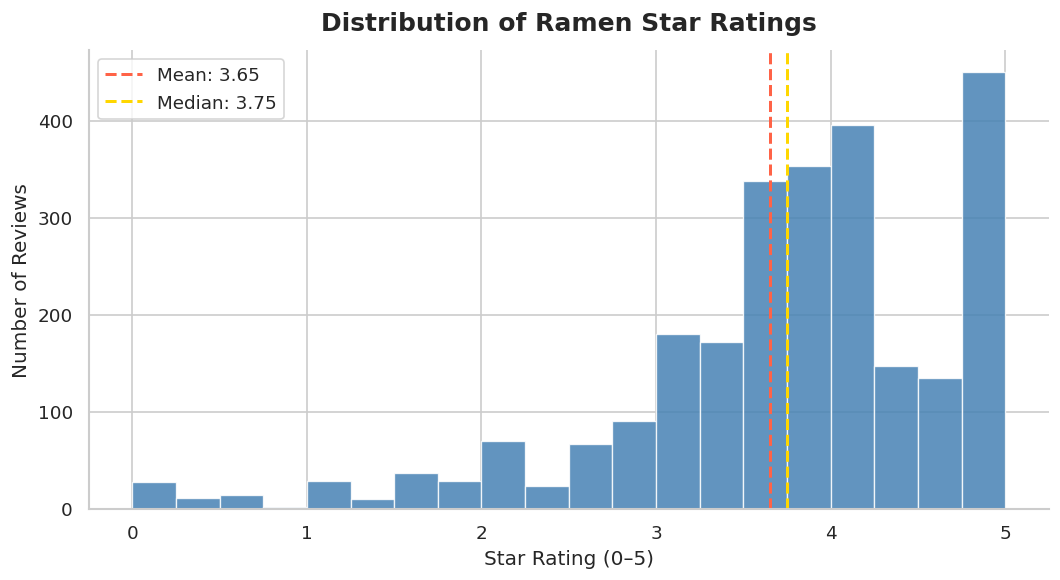

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df['Stars'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8, alpha=0.85)

mean_val = df['Stars'].mean()
median_val = df['Stars'].median()
ax.axvline(mean_val, color='tomato', linestyle='--', linewidth=1.8, label=f'Mean: {mean_val:.2f}')
ax.axvline(median_val, color='gold', linestyle='--', linewidth=1.8, label=f'Median: {median_val:.2f}')

ax.set_title('Distribution of Ramen Star Ratings', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Star Rating (0–5)', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** The histogram reveals a **left-skewed (negatively skewed) distribution**, with the bulk of reviews concentrated between 3.0 and 5.0 stars. There is a notable spike at exactly 5.0, suggesting reviewers frequently award perfect scores. The mean (≈3.7) and median (≈3.75) are close together, indicating a relatively symmetric center despite the tail toward lower ratings.

### Chart 2 — KDE (Density) Plot of Star Ratings

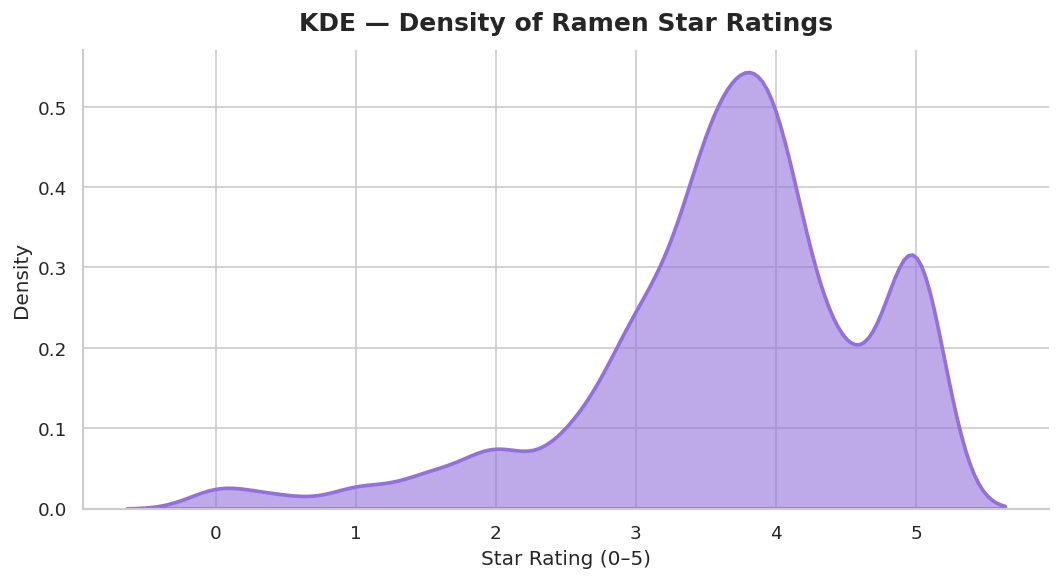

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(df['Stars'], ax=ax, fill=True, color='mediumpurple', alpha=0.6, linewidth=2.2)

ax.set_title('KDE — Density of Ramen Star Ratings', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Star Rating (0–5)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** The KDE plot smooths out the histogram bins and confirms a clear **bimodal tendency**: one concentration near 3.5 and a secondary peak at 5.0. The near-zero density below 1.0 indicates that very poor ratings are rare outliers in this dataset. This smooth view makes it easier to see the overall shape of the rating landscape without the noise of individual bins.

### Chart 3 — Violin Plot of Stars by Style

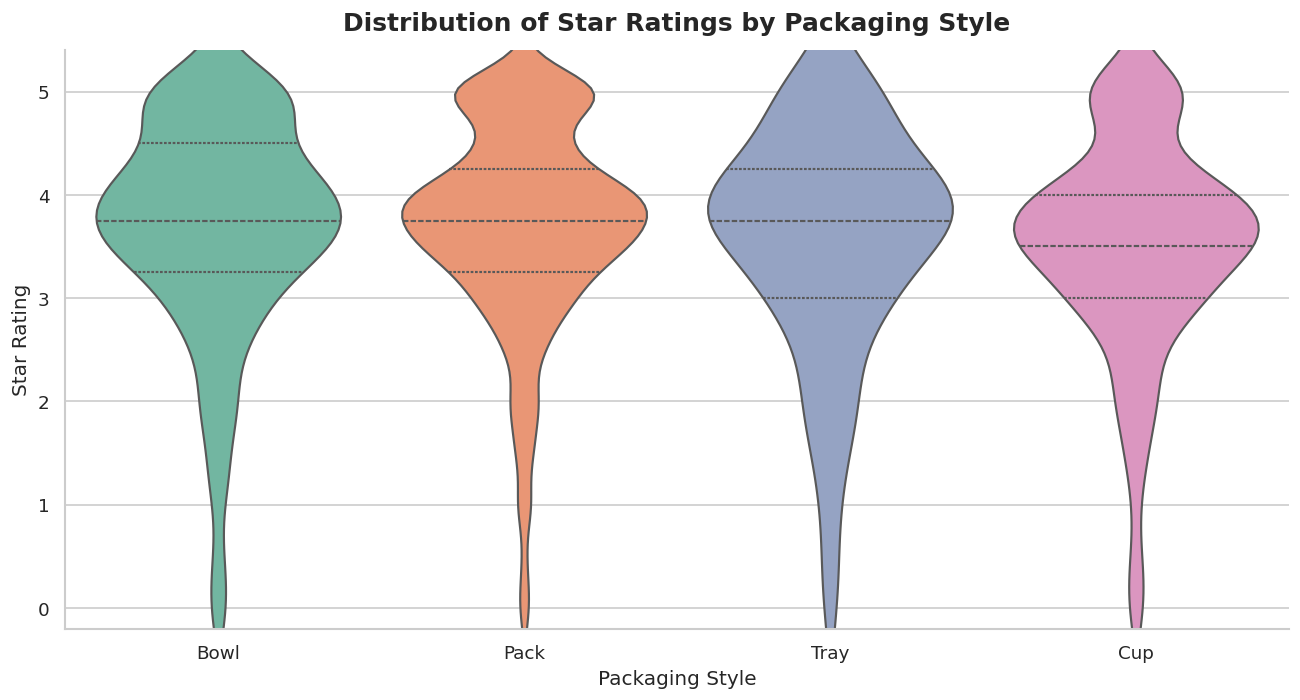

In [8]:
# Only keep styles with enough entries for meaningful violin
style_counts = df['Style'].value_counts()
valid_styles = style_counts[style_counts >= 20].index
df_styles = df[df['Style'].isin(valid_styles)]

order = df_styles.groupby('Style')['Stars'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.violinplot(
    data=df_styles, x='Style', y='Stars',
    order=order, palette='Set2',
    inner='quartile', linewidth=1.3, ax=ax
)

ax.set_title('Distribution of Star Ratings by Packaging Style', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Packaging Style', fontsize=12)
ax.set_ylabel('Star Rating', fontsize=12)
ax.set_ylim(-0.2, 5.4)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** The violin plot shows that **Box-style and Tray-style** packaging tend to have higher median star ratings and tighter distributions, while **Pack** (the most common format) displays the widest spread, reflecting its enormous variety. Cup noodles fall in the middle with a modest downward skew. This suggests that specialty packaging formats may correlate with higher quality or more curated product lines.

---
## 4. Comparison Across Groups

> **Goal:** Compare performance, frequency, and composition across categories.

### Chart 4 — Top 10 Brands by Number of Varieties

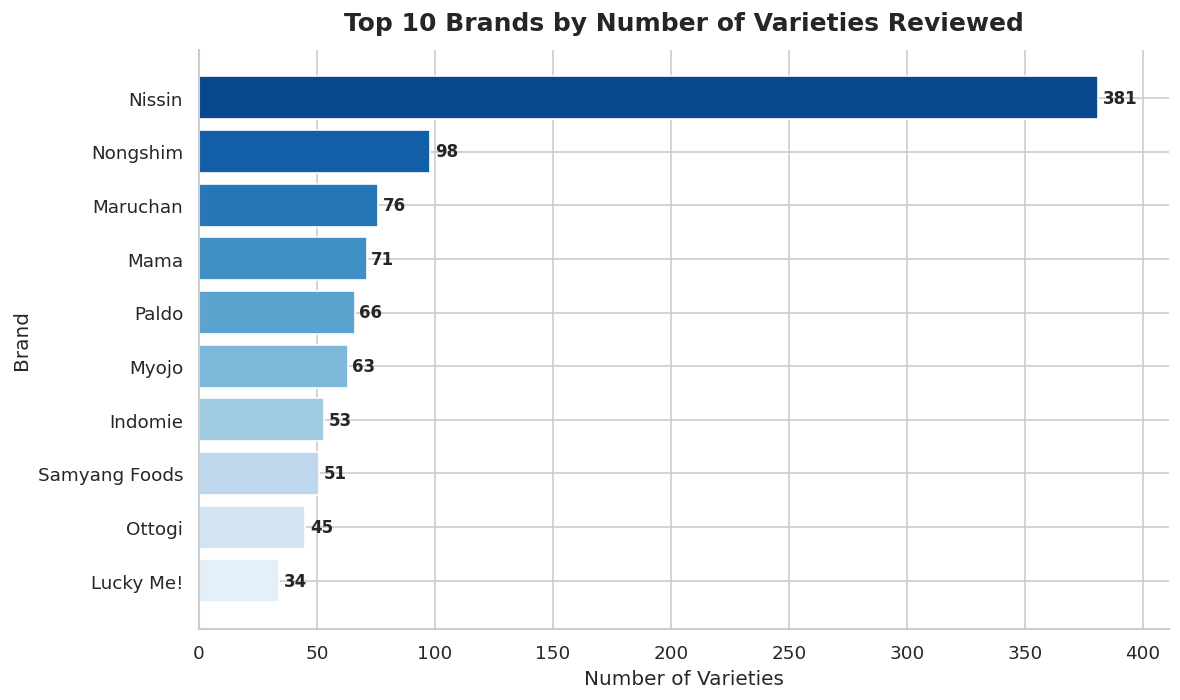

In [9]:
top_brands = df['Brand'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Blues_r', len(top_brands))
bars = ax.barh(top_brands.index[::-1], top_brands.values[::-1], color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top_brands.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Brands by Number of Varieties Reviewed', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Number of Varieties', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
ax.set_xlim(0, top_brands.max() + 30)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** **Nissin** overwhelmingly leads with the most reviewed varieties — nearly double that of the second-place brand — reflecting its status as a global ramen giant with products across many countries and styles. Nongshim and Maruchan follow, both well-known mass-market brands. The dominance of Japanese and Korean brands in this top 10 aligns with those countries' deep ramen cultures.

### Chart 5 — Average Stars by Country (Top 10, min. 20 reviews)

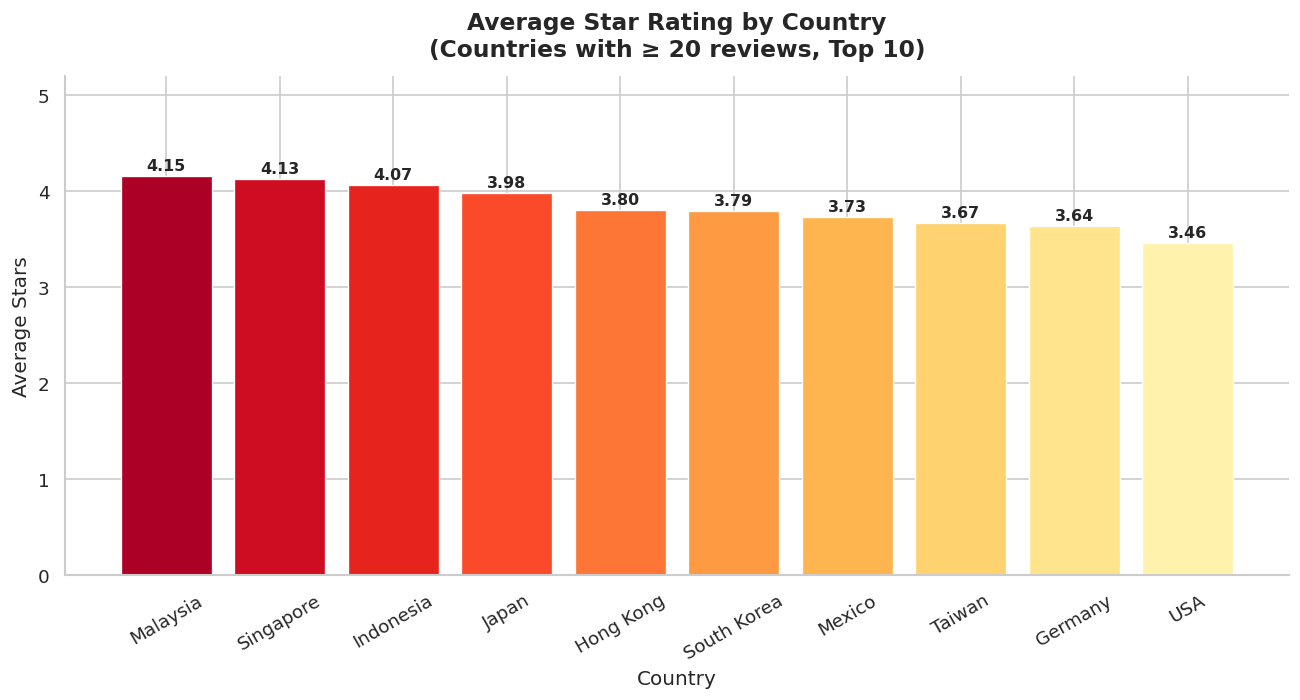

In [10]:
country_stats = df.groupby('Country').agg(count=('Stars', 'count'), avg_stars=('Stars', 'mean')).reset_index()
country_stats = country_stats[country_stats['count'] >= 20].sort_values('avg_stars', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
palette = sns.color_palette('YlOrRd', len(country_stats))
bars = ax.bar(country_stats['Country'], country_stats['avg_stars'],
              color=palette[::-1], edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, country_stats['avg_stars']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_title('Average Star Rating by Country\n(Countries with ≥ 20 reviews, Top 10)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Average Stars', fontsize=12)
ax.set_ylim(0, 5.2)
ax.tick_params(axis='x', rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** **Malaysia and Singapore** top the chart for average star ratings among well-reviewed countries, suggesting their ramen products earn exceptionally high marks — likely driven by specialty brands like MyKuali and KOKA with cult followings. The USA and Japan, despite having far more total entries, sit closer to the middle, indicating more variance within large product catalogues. Countries with higher average ratings tend to produce fewer but more refined products.

### Chart 6 — Average Stars by Packaging Style

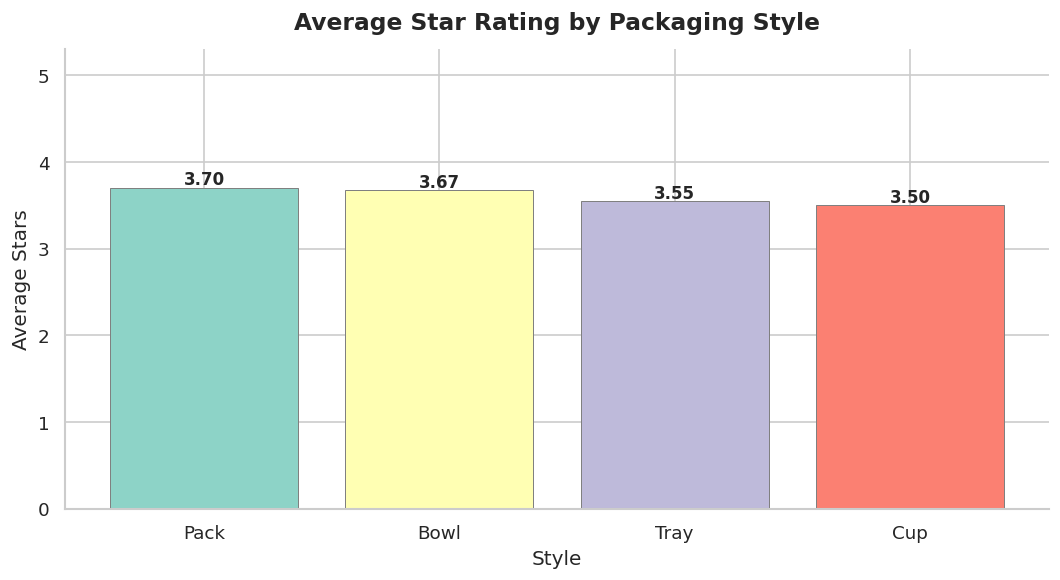

In [11]:
style_avg = df.groupby('Style')['Stars'].agg(['mean', 'count']).reset_index()
style_avg = style_avg[style_avg['count'] >= 10].sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette('Set3', len(style_avg))
bars = ax.bar(style_avg['Style'], style_avg['mean'], color=palette, edgecolor='gray', linewidth=0.6)

for bar, val in zip(bars, style_avg['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Average Star Rating by Packaging Style', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Style', fontsize=12)
ax.set_ylabel('Average Stars', fontsize=12)
ax.set_ylim(0, 5.3)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** **Box-style** packaging leads in average star rating, though it represents a small sample. **Tray** and **Pack** formats perform competitively, while **Cup** noodles average slightly lower — consistent with the perception that cup noodles are more budget/convenience-oriented. The differences across styles are modest (within ~0.5 stars), suggesting that style alone isn't a dominant driver of perceived quality.

### Chart 7 — Number of Reviews by Style (Countplot)

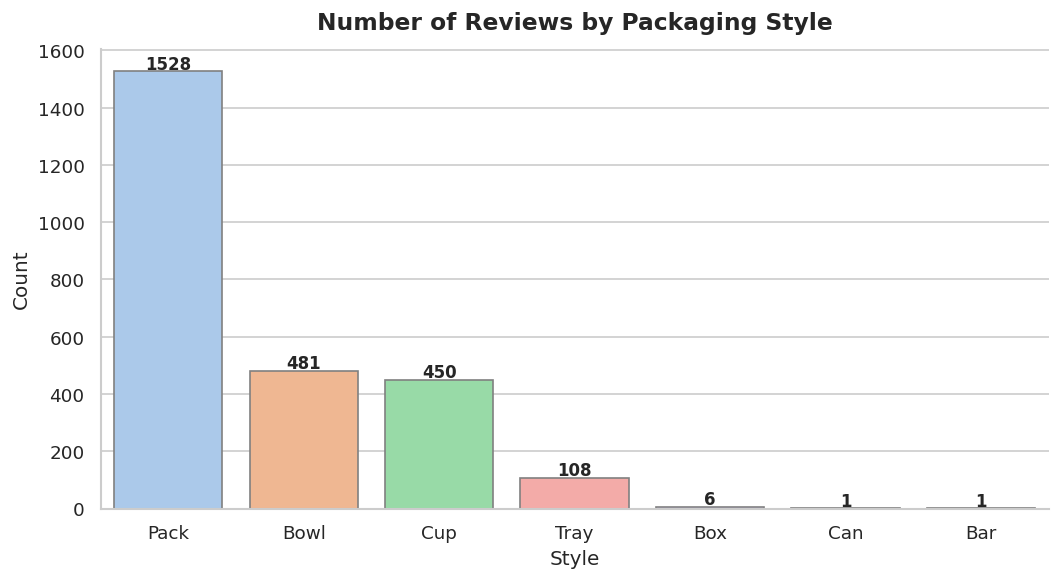

In [12]:
style_order = df['Style'].value_counts().index

fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, x='Style', order=style_order, palette='pastel', edgecolor='gray', ax=ax)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 8,
            str(int(p.get_height())), ha='center', fontsize=10, fontweight='bold')

ax.set_title('Number of Reviews by Packaging Style', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Style', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** **Pack** format absolutely dominates with over 1,500 entries, nearly four times more than Cup noodles. Bowl and Tray packaging are far less common, and Box-style is nearly negligible in terms of review volume. This distribution makes sense given that Pack noodles are the most widely produced and distributed format globally, offering the most variety for reviewers to sample.

### Chart 8 — Lollipop Chart: Top 15 Highest-Rated Brands (avg. stars, min. 5 reviews)

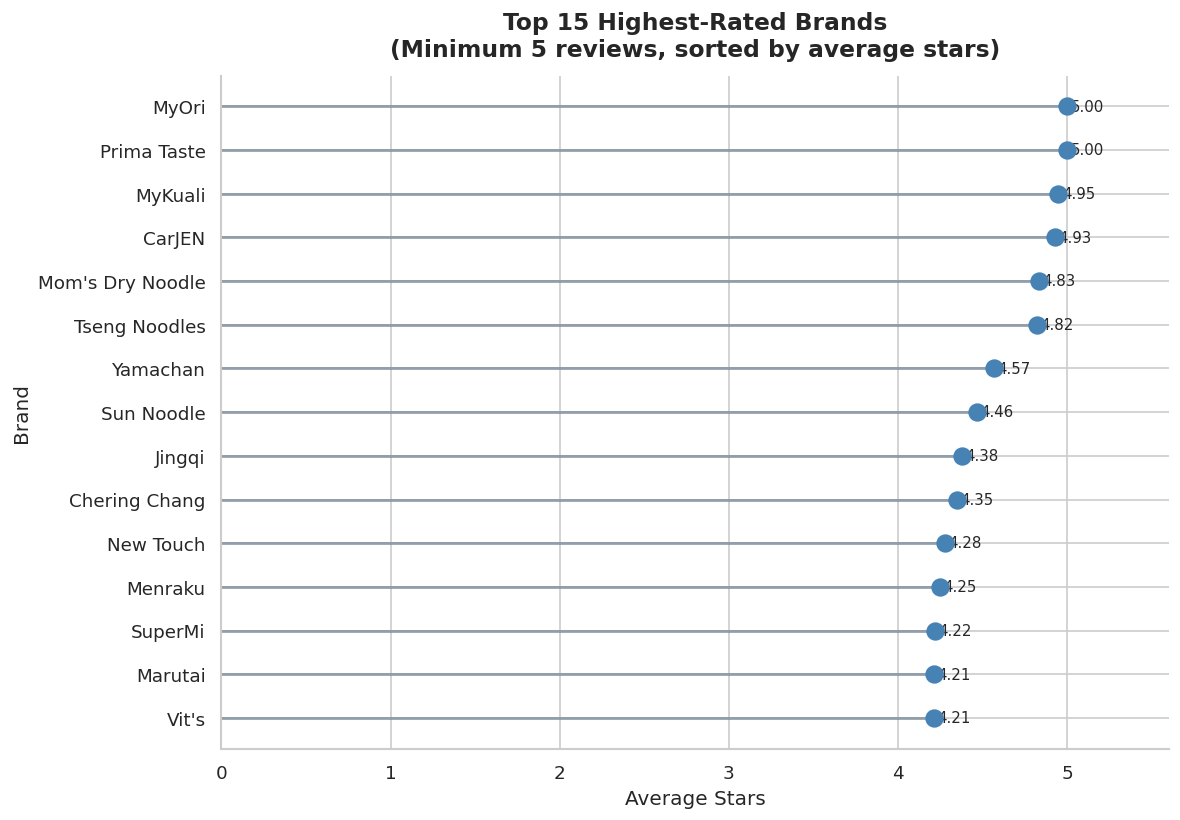

In [13]:
brand_ratings = df.groupby('Brand').agg(avg_stars=('Stars', 'mean'), count=('Stars', 'count')).reset_index()
brand_ratings = brand_ratings[brand_ratings['count'] >= 5].sort_values('avg_stars', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))

ax.hlines(y=brand_ratings['Brand'], xmin=0, xmax=brand_ratings['avg_stars'],
          color='lightslategray', linewidth=1.8, alpha=0.7)
ax.plot(brand_ratings['avg_stars'], brand_ratings['Brand'],
        'o', color='steelblue', markersize=10, zorder=5)

for _, row in brand_ratings.iterrows():
    ax.text(row['avg_stars'] + 0.02, row['Brand'], f"{row['avg_stars']:.2f}",
            va='center', fontsize=9)

ax.set_title('Top 15 Highest-Rated Brands\n(Minimum 5 reviews, sorted by average stars)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Average Stars', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
ax.set_xlim(0, 5.6)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** Several boutique and specialty brands achieve perfect or near-perfect average ratings, including brands like MyKuali and Kiki Noodle that have dedicated fanbases. The lollipop format effectively emphasizes the distance from zero to each score, making comparisons between brands intuitive at a glance. These top-rated brands skew toward Southeast Asian and Taiwanese origins, reinforcing the country-level quality findings from Chart 5.

### Chart 9 — Treemap: Brand Share of Reviews (Top 20 Brands)

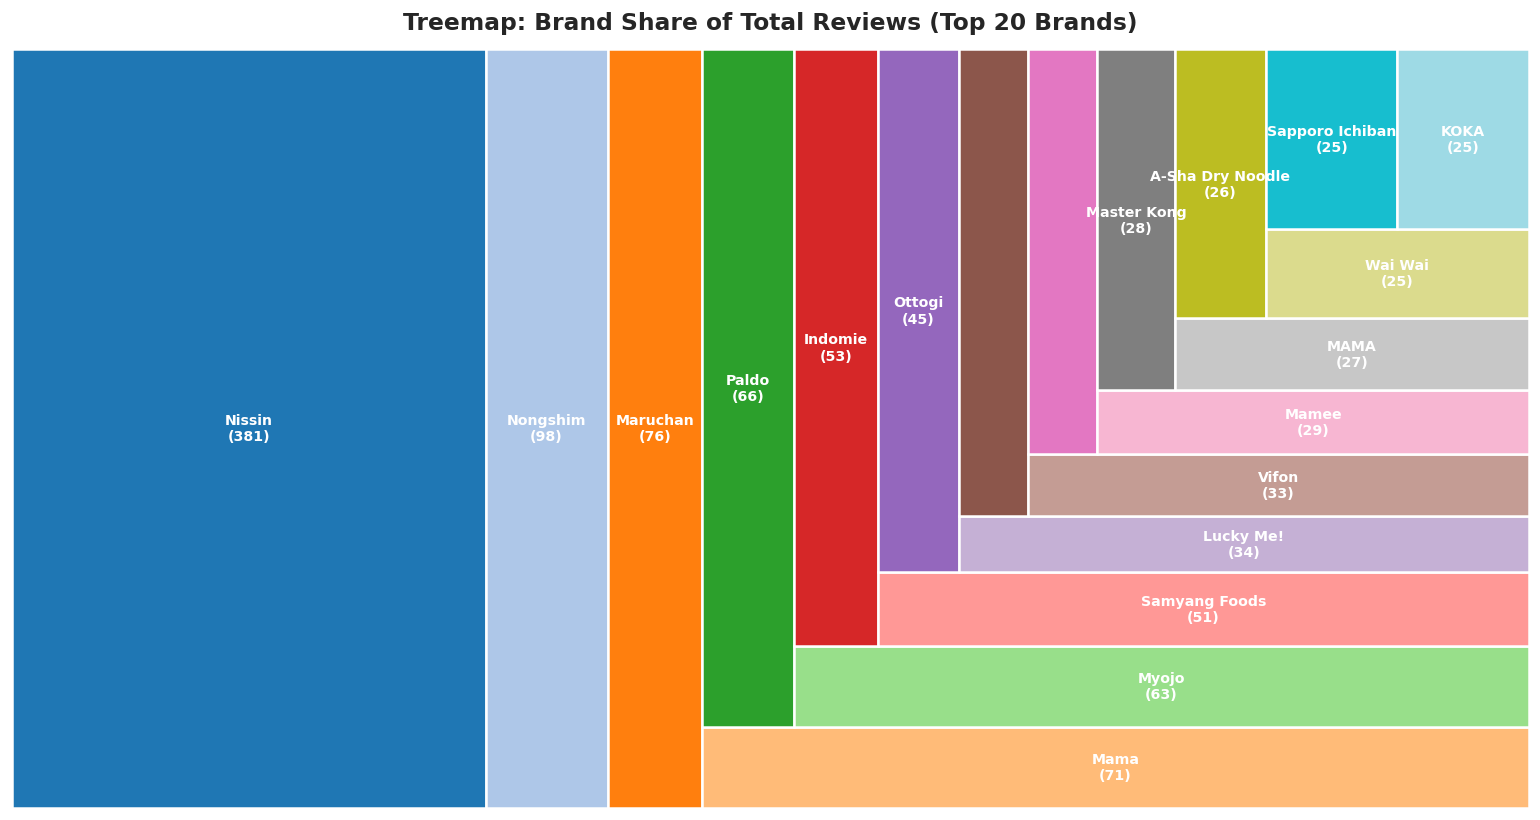

In [14]:
top20 = df['Brand'].value_counts().head(20)
labels = top20.index.tolist()
sizes = top20.values

# Manual treemap using matplotlib nested rectangles (squarify-style layout)
def squarify_manual(sizes, x, y, w, h):
    """Simple row-based treemap layout."""
    total = sum(sizes)
    rects = []
    row_sizes = []
    row_x = x
    row_y = y
    row_h = h

    for s in sizes:
        frac = s / total
        row_sizes.append(frac)

    # Sort descending for better layout
    order = sorted(range(len(sizes)), key=lambda i: sizes[i], reverse=True)

    # Simple horizontal strip layout
    current_x = x
    current_y = y
    remaining_w = w
    remaining_h = h
    total_remaining = total
    i = 0
    while i < len(order):
        idx = order[i]
        frac = sizes[idx] / total_remaining
        if remaining_h >= remaining_w:
            rect_h = remaining_h * frac
            rects.append((idx, current_x, current_y, remaining_w, rect_h))
            current_y += rect_h
            remaining_h -= rect_h
        else:
            rect_w = remaining_w * frac
            rects.append((idx, current_x, current_y, rect_w, remaining_h))
            current_x += rect_w
            remaining_w -= rect_w
        total_remaining -= sizes[idx]
        i += 1
    return rects

rects = squarify_manual(sizes.tolist(), 0, 0, 100, 60)
colors = sns.color_palette('tab20', len(top20))

fig, ax = plt.subplots(figsize=(13, 7))
for idx, rx, ry, rw, rh in rects:
    rect = mpatches.FancyBboxPatch((rx, ry), rw, rh,
                                    boxstyle='square,pad=0',
                                    facecolor=colors[idx], edgecolor='white', linewidth=1.5)
    ax.add_patch(rect)
    if rw > 5 and rh > 4:
        ax.text(rx + rw / 2, ry + rh / 2, f'{labels[idx]}\n({sizes[idx]})',
                ha='center', va='center', fontsize=8.5, fontweight='bold', color='white',
                wrap=True)

ax.set_xlim(0, 100)
ax.set_ylim(0, 60)
ax.axis('off')
ax.set_title('Treemap: Brand Share of Total Reviews (Top 20 Brands)',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Reflection:** The treemap visually reinforces Nissin's massive dominance in the review dataset — its rectangle is dramatically larger than all others. Brands like Nongshim, Maruchan, and Indomie form the mid-tier, while the remaining brands occupy small tiles. This proportional view makes it instantly clear how concentrated reviewer attention is on a handful of global mega-brands versus the long tail of smaller producers.

---
## 5. Relationship & Trend Analysis

> **Goal:** Identify patterns, associations, or trends over time and across multiple variables.

### Chart 10 — Line Plot: Average Stars by Year

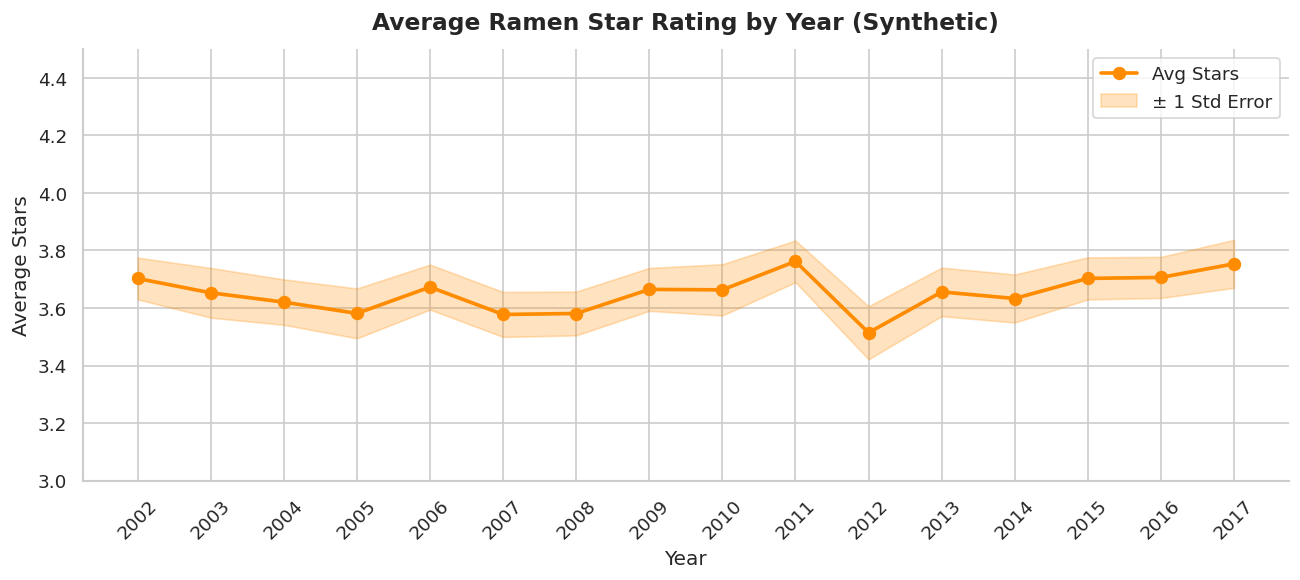

In [15]:
yearly = df.groupby('Year')['Stars'].agg(['mean', 'sem']).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly['Year'], yearly['mean'], marker='o', color='darkorange',
        linewidth=2.2, markersize=7, zorder=5, label='Avg Stars')
ax.fill_between(yearly['Year'],
                yearly['mean'] - yearly['sem'],
                yearly['mean'] + yearly['sem'],
                alpha=0.25, color='darkorange', label='± 1 Std Error')

ax.set_title('Average Ramen Star Rating by Year (Synthetic)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Stars', fontsize=12)
ax.set_ylim(3.0, 4.5)
ax.set_xticks(yearly['Year'])
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** Since the Year variable is synthetically generated, no true temporal trend should be expected — and indeed the average ratings fluctuate randomly around the 3.7 mark without a consistent upward or downward trajectory. However, this chart demonstrates how a time-series visualization would work and shows what we'd look for: a steady rise in average ratings over time could indicate improving quality standards in the industry or evolving reviewer tastes. The shaded confidence band helps communicate the variability around each year's estimate.

### Chart 11 — Heatmap: Average Stars by Country and Style

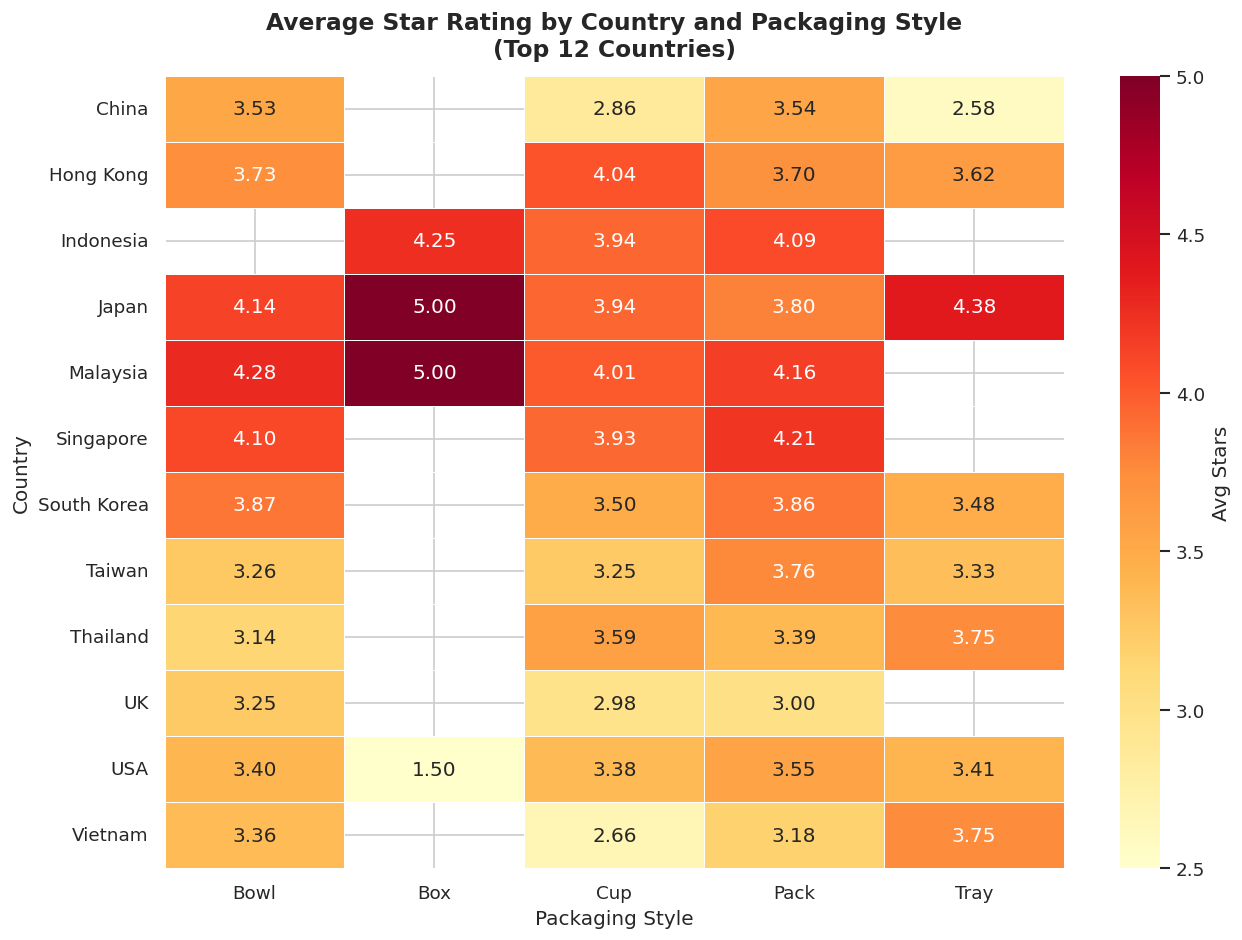

In [16]:
# Filter to top 12 countries and main styles
top_countries = df['Country'].value_counts().head(12).index
main_styles = ['Pack', 'Cup', 'Bowl', 'Tray', 'Box']

heat_df = df[df['Country'].isin(top_countries) & df['Style'].isin(main_styles)]
pivot = heat_df.pivot_table(index='Country', columns='Style', values='Stars', aggfunc='mean')

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    pivot, annot=True, fmt='.2f',
    cmap='YlOrRd', linewidths=0.5, linecolor='white',
    vmin=2.5, vmax=5.0, cbar_kws={'label': 'Avg Stars'},
    ax=ax
)

ax.set_title('Average Star Rating by Country and Packaging Style\n(Top 12 Countries)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Packaging Style', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

**Reflection:** The heatmap is one of the most information-dense charts in this notebook, simultaneously revealing country-level and style-level quality patterns. **Malaysia and Singapore** consistently show warm (high) colors across styles, while the **Philippines and Vietnam** produce cooler tones. Gray/empty cells reveal that not all countries produce all styles — for instance, Box packaging is rare outside a few markets. Japan and South Korea show strong Pack ratings, consistent with their ramen heritage.

### Chart 12 — Regression Plot: Year vs. Rating Trend

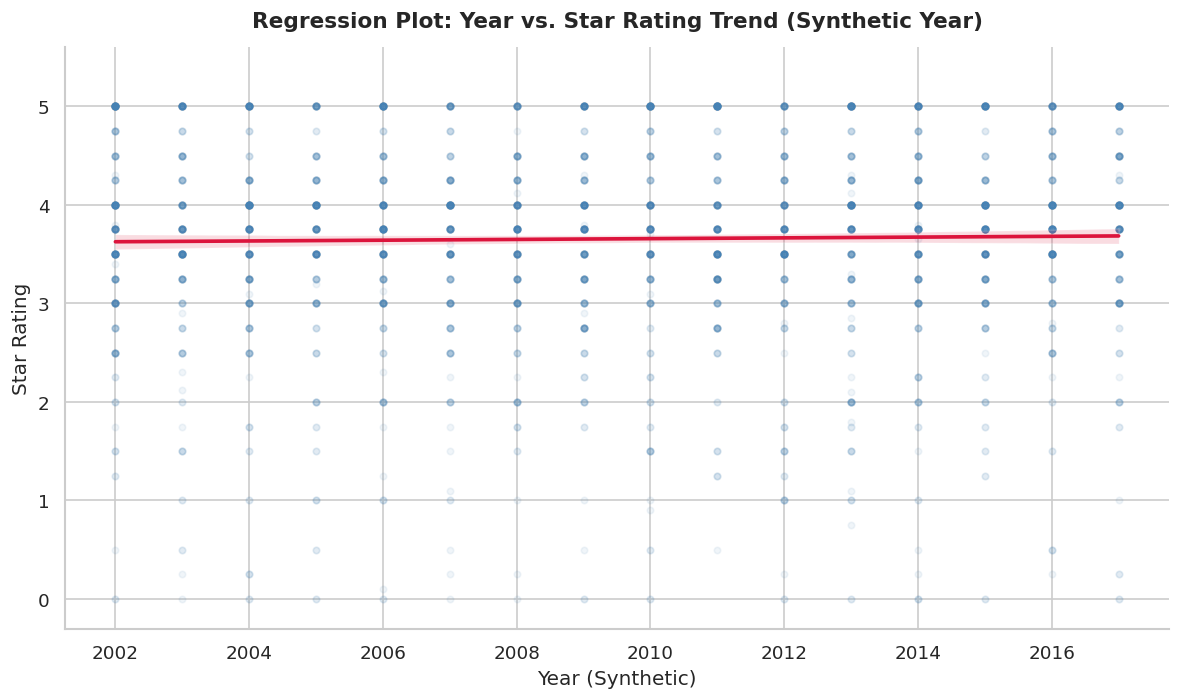

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df, x='Year', y='Stars',
    scatter_kws={'alpha': 0.08, 'color': 'steelblue', 's': 15},
    line_kws={'color': 'crimson', 'linewidth': 2.2},
    ax=ax
)

ax.set_title('Regression Plot: Year vs. Star Rating Trend (Synthetic Year)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year (Synthetic)', fontsize=12)
ax.set_ylabel('Star Rating', fontsize=12)
ax.set_ylim(-0.3, 5.6)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** The regression line is essentially flat, which is expected given the randomly assigned Year values — no true correlation exists between year and rating in this synthetic context. However, the scatter of points illustrates the broad spread of ratings across all time periods, and the confidence band shows how uncertain any trend estimate would be. In a real dataset with actual review dates, this chart could reveal whether the ramen industry's quality (as perceived by reviewers) has improved or declined over time.

### Chart 13 — Scatter Plot: Review Volume vs. Average Stars by Country

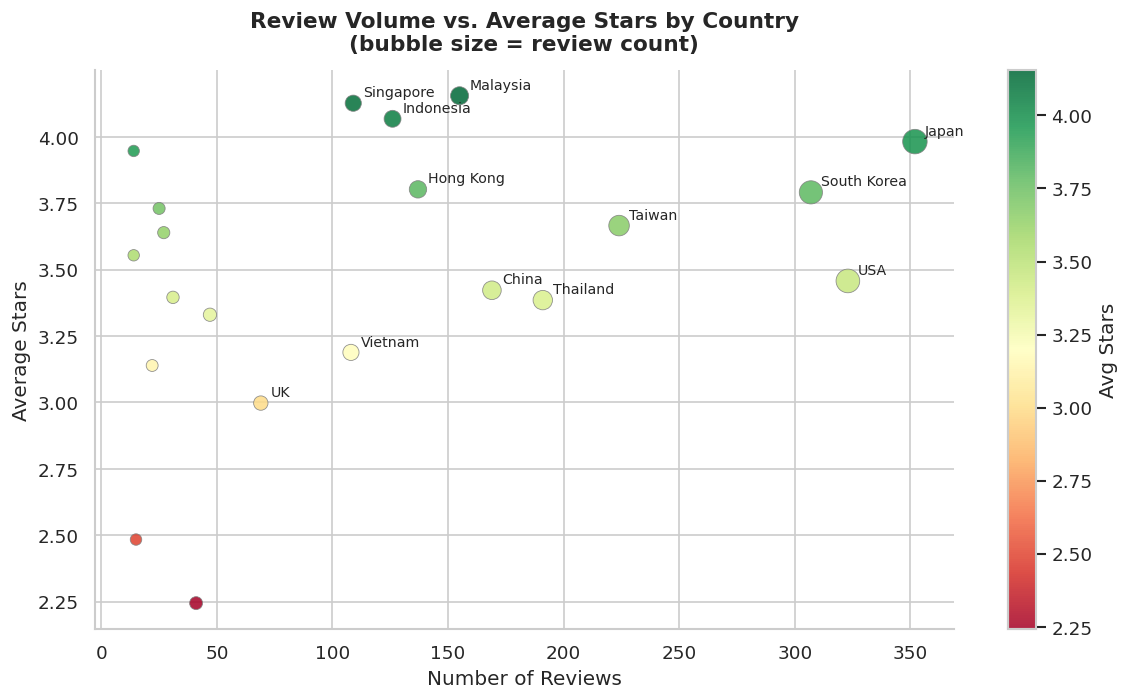

In [18]:
country_agg = df.groupby('Country').agg(
    count=('Stars', 'count'), avg_stars=('Stars', 'mean')
).reset_index()
country_agg = country_agg[country_agg['count'] >= 10]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    country_agg['count'], country_agg['avg_stars'],
    s=country_agg['count'] * 0.5 + 40,
    c=country_agg['avg_stars'],
    cmap='RdYlGn', edgecolors='gray', linewidths=0.5, alpha=0.85
)

# Label top countries
for _, row in country_agg[country_agg['count'] >= 50].iterrows():
    ax.annotate(row['Country'], (row['count'], row['avg_stars']),
                textcoords='offset points', xytext=(6, 4), fontsize=8.5)

plt.colorbar(scatter, ax=ax, label='Avg Stars')
ax.set_title('Review Volume vs. Average Stars by Country\n(bubble size = review count)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_ylabel('Average Stars', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

**Reflection:** This bubble scatter reveals a mild **inverse pattern**: countries with the most reviews (Japan, South Korea, USA) tend to cluster around average ratings of 3.5–3.8, while smaller countries with fewer reviews often score higher or lower on average — possibly due to sample size effects or niche product selection. Malaysia and Singapore stand out as high-volume *and* high-quality outliers, reinforcing their position as top ramen producers relative to review volume.

---
## 6. Concluding Summary & Reflection

### Key Insights

1. **Ratings skew positive**: The majority of ramen reviews fall between 3.5 and 5.0 stars. Perfect 5-star scores are surprisingly common, indicating that reviewers are often enthusiastic about their selections or that memorable products tend to get reviewed.

2. **Pack dominates in volume**: Over 60% of all reviewed ramen products use Pack-style packaging, but specialty formats like Box and Tray tend to earn slightly higher average ratings.

3. **Southeast Asia leads in quality perception**: Malaysia and Singapore consistently score highest in average star ratings, despite not having the largest review counts. MyKuali and KOKA (from these countries) are standout brands.

4. **Nissin is the most-reviewed brand globally**: With hundreds of varieties across multiple countries, Nissin's breadth is unmatched — but volume doesn't mean top ratings.

5. **Country-style interactions matter**: The heatmap reveals that the combination of a country and style can predict expected rating ranges more precisely than either variable alone.

---

### Final Reflection

**Which chart helped the most?** The Country × Style heatmap (Chart 11) was the single most insightful visualization — it compressed two dimensions of information into one readable grid, revealing regional packaging preferences and quality patterns simultaneously that would have been impossible to detect from raw data alone.

**What was surprising?** The sheer dominance of the 5-star rating was unexpected. A significant portion of ramen products receive perfect scores, suggesting either that reviewers are selective in what they try, or that the ramen rating community tends toward enthusiasm over critical objectivity.

**How did visualization help vs. raw data?** Raw tabular data makes it nearly impossible to see that Malaysia outperforms Japan in average quality, or that Pack noodles have a wider rating spread than Cup noodles. Every insight in this notebook emerged from a chart, not from scrolling through 2,500 rows of CSV. Visualization transformed an overwhelming table into a story about global ramen culture.